In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos los datos de Regresión
df_bpn = pd.read_csv('../data/raw/BPN.csv')

# 2. Un vistazo rápido a las variables
print("--- INFO DEL DATASET BPN ---")
print(df_bpn.info())
df_bpn.head()

--- INFO DEL DATASET BPN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10187 entries, 0 to 10186
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             10187 non-null  int64 
 1   semana         10187 non-null  int64 
 2   edad_          10187 non-null  int64 
 3   uni_med_       10187 non-null  int64 
 4   sexo_          10187 non-null  object
 5   nombre_barrio  10187 non-null  object
 6   comuna         10187 non-null  object
 7   tipo_ss_       10187 non-null  object
 8   cod_ase_       10187 non-null  object
 9   fec_con_       10187 non-null  object
 10  ini_sin_       10187 non-null  object
 11  tip_cas_       10187 non-null  int64 
 12  pac_hos_       10187 non-null  int64 
 13  peso_nacer     10187 non-null  object
 14  talla_nacer    10187 non-null  object
 15  sem_gest       10187 non-null  object
 16  niv_edu_ma     10187 non-null  object
 17  evento         10187 non-null  object
 1

,id,semana,edad_,uni_med_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,ini_sin_,tip_cas_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,evento,year_
0,1,41,28,1,M,Oriente,Manrique,N,"\""\""",01/01/1900,01/01/1900,4,1,2440,49,38,SD,BAJO PESO AL NACER,2011
1,2,41,17,1,F,SIN INFORMACION,SIN INFORMACION,S,EPS003,01/01/1900,01/01/1900,4,1,2490,46,37,SD,BAJO PESO AL NACER,2011
2,3,44,19,1,F,Villa del Socorro,Santa Cruz,S,EPS003,01/01/1900,01/01/1900,4,1,2290,47,37,SD,BAJO PESO AL NACER,2011
3,4,47,27,1,F,Las Independencias,San Javier,S,EPS003,01/01/1900,01/01/1900,4,1,2400,49,37,SD,BAJO PESO AL NACER,2011
4,5,47,23,1,F,Granizal,Popular,N,"\""\""",01/01/1900,01/01/1900,4,1,2240,47,38,SD,BAJO PESO AL NACER,2011


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos los datos de Regresión
df_bpn = pd.read_csv('../data/raw/BPN.csv')

# 2. Identificar tipos de variables
numeric_cols_bpn = df_bpn.select_dtypes(include=['number']).columns.tolist()
categorical_cols_bpn = df_bpn.select_dtypes(include=['object']).columns.tolist()

print(f"--- PASO 1: Identificación de Variables (BPN) ---")
print(f"Variables Numéricas ({len(numeric_cols_bpn)}): {numeric_cols_bpn}")
print(f"Variables Categóricas ({len(categorical_cols_bpn)}): {categorical_cols_bpn}")

# Vistazo a los datos
df_bpn.head()

--- PASO 1: Identificación de Variables (BPN) ---
Variables Numéricas (7): ['id', 'semana', 'edad_', 'uni_med_', 'tip_cas_', 'pac_hos_', 'year_']
Variables Categóricas (12): ['sexo_', 'nombre_barrio', 'comuna', 'tipo_ss_', 'cod_ase_', 'fec_con_', 'ini_sin_', 'peso_nacer', 'talla_nacer', 'sem_gest', 'niv_edu_ma', 'evento']


,id,semana,edad_,uni_med_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,ini_sin_,tip_cas_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,evento,year_
0,1,41,28,1,M,Oriente,Manrique,N,"\""\""",01/01/1900,01/01/1900,4,1,2440,49,38,SD,BAJO PESO AL NACER,2011
1,2,41,17,1,F,SIN INFORMACION,SIN INFORMACION,S,EPS003,01/01/1900,01/01/1900,4,1,2490,46,37,SD,BAJO PESO AL NACER,2011
2,3,44,19,1,F,Villa del Socorro,Santa Cruz,S,EPS003,01/01/1900,01/01/1900,4,1,2290,47,37,SD,BAJO PESO AL NACER,2011
3,4,47,27,1,F,Las Independencias,San Javier,S,EPS003,01/01/1900,01/01/1900,4,1,2400,49,37,SD,BAJO PESO AL NACER,2011
4,5,47,23,1,F,Granizal,Popular,N,"\""\""",01/01/1900,01/01/1900,4,1,2240,47,38,SD,BAJO PESO AL NACER,2011


In [ ]:
import numpy as np

# 1. Eliminar variables que no sirven para el modelo 
columnas_basura = ['id', 'uni_med_', 'tip_cas_', 'fec_con_', 'ini_sin_', 'cod_ase_']
# Usamos errors='ignore' por si alguna se llama 'ID' en mayúscula
df_bpn = df_bpn.drop(columns=[c for c in columnas_basura if c in df_bpn.columns], errors='ignore') 
# También intentamos con mayúscula por si acaso
df_bpn = df_bpn.drop(columns=['ID'], errors='ignore')

# 2. Rescatar las variables numéricas secuestradas por el texto "SD"
variables_rescatar = ['peso_nacer', 'talla_nace', 'sem_gest', 'niv_edu_ma']

print("--- LIMPIEZA DE DATOS ---")
for col in variables_rescatar:
    if col in df_bpn.columns:
        # Reemplazamos "SD" (Sin Dato) por un valor nulo matemático (NaN)
        # y forzamos a que la columna vuelva a ser numérica
        df_bpn[col] = pd.to_numeric(df_bpn[col].replace('SD', np.nan), errors='coerce')
        print(f"Columna '{col}' convertida a numérica con éxito.")

# 3. Volver a clasificar (ahora sí, con el peso_nacer como número)
numeric_cols_bpn = df_bpn.select_dtypes(include=['number']).columns.tolist()
categorical_cols_bpn = df_bpn.select_dtypes(include=['object']).columns.tolist()

print("\nNuevas Numéricas listas para analizar:", numeric_cols_bpn)

--- LIMPIEZA DE DATOS ---
Columna 'peso_nacer' convertida a numérica con éxito.
Columna 'sem_gest' convertida a numérica con éxito.
Columna 'niv_edu_ma' convertida a numérica con éxito.

Nuevas Numéricas listas para analizar: ['semana', 'edad_', 'pac_hos_', 'peso_nacer', 'sem_gest', 'niv_edu_ma', 'year_']


In [6]:
# 2.1. Estadísticas para variables numéricas (Media, Mediana, Desviación, etc.)
print("--- ESTADÍSTICAS NUMÉRICAS (BPN) ---")
desc_num_bpn = df_bpn[numeric_cols_bpn].describe().T
desc_num_bpn['median'] = df_bpn[numeric_cols_bpn].median()
print(desc_num_bpn[['mean', 'median', 'std', 'min', 'max']])

# 2.2. Frecuencias para variables categóricas
print("\n--- FRECUENCIA DE CATEGÓRICAS (BPN) ---")
for col in categorical_cols_bpn:
    print(f"\nColumna: {col}")
    print(df_bpn[col].value_counts())

--- ESTADÍSTICAS NUMÉRICAS (BPN) ---
                   mean  median         std     min     max
semana        27.027977    28.0   14.675129     1.0    53.0
edad_         25.572593    25.0    6.749109     5.0    57.0
pac_hos_       1.368313     1.0    0.482370     1.0     2.0
peso_nacer  2313.819048  2360.0  167.324251   900.0  2499.0
sem_gest      37.654885    37.0    0.869416    37.0    45.0
niv_edu_ma     2.241788     2.0    0.649766     1.0     5.0
year_       2016.594778  2017.0    2.837770  2011.0  2021.0

--- FRECUENCIA DE CATEGÓRICAS (BPN) ---

Columna: sexo_
sexo_
F    10171
M       16
Name: count, dtype: int64

Columna: nombre_barrio
nombre_barrio
SIN INFORMACION         338
San Antonio de Prado    210
Moravia                 134
Popular                 131
Robledo                 131
                       ... 
Boqueron                  1
CorazÃ³n de JesÃºs        1
El Vergel                 1
Santa MÃ³nica             1
San Jose la Cima N.1      1
Name: count, Length: 450, 

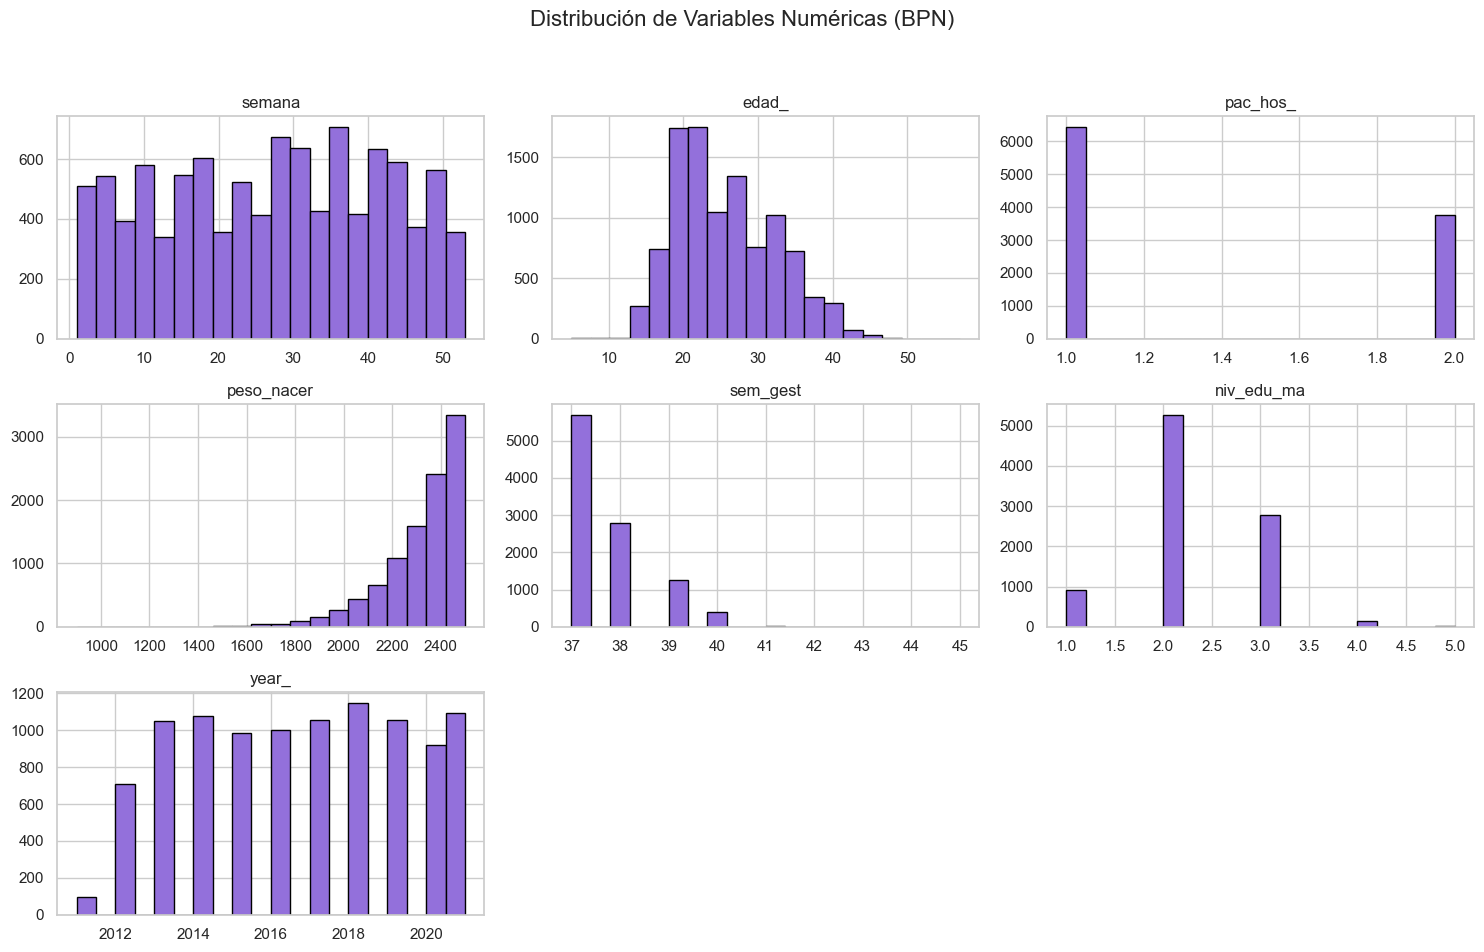

In [ ]:
# 2.3. Distribuciones (Histogramas)
sns.set_theme(style="whitegrid")

# Generamos los histogramas. 
df_bpn[numeric_cols_bpn].hist(bins=20, figsize=(15, 10), color='mediumpurple', edgecolor='black')

plt.suptitle("Distribución de Variables Numéricas (BPN)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

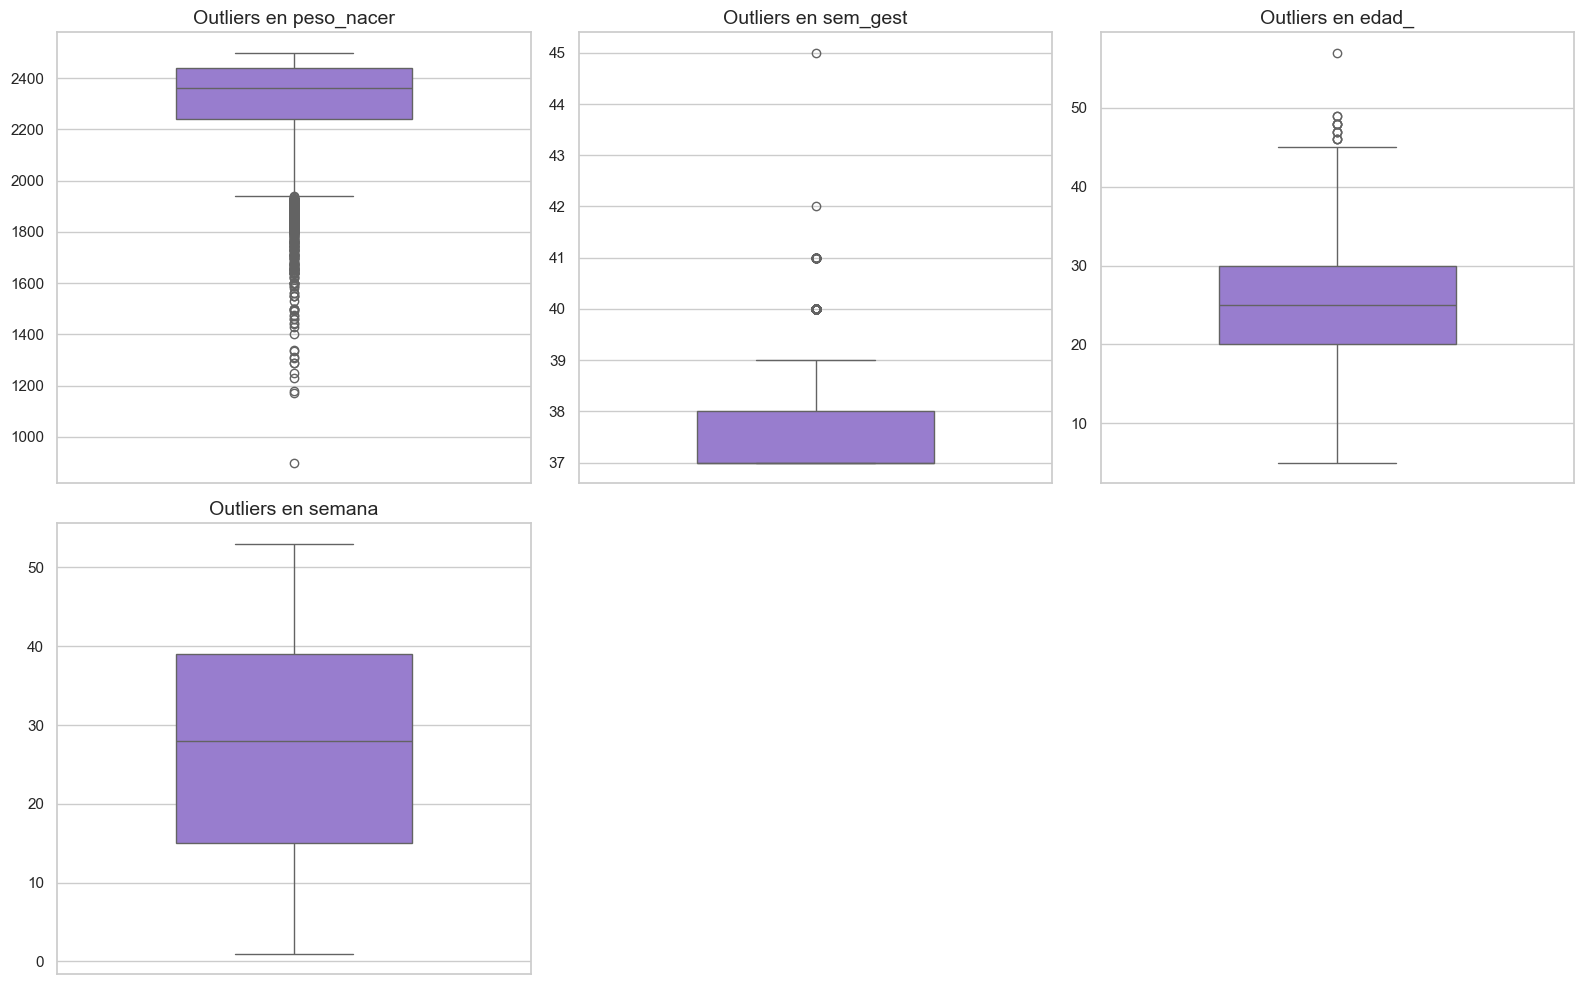

In [8]:
# 3. Identificación de Outliers
# Filtramos solo las variables que son realmente medidas físicas o de tiempo
cols_continuas = ['peso_nacer', 'talla_nace', 'sem_gest', 'edad_', 'semana']

# Asegurarnos de graficar solo las que existen en el dataframe (por si alguna falta)
cols_graficar = [c for c in cols_continuas if c in df_bpn.columns]

# Configurar el lienzo
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

# Dibujar las cajas
for i, col in enumerate(cols_graficar):
    # Usamos un color distinto para mantener el estilo de este notebook
    sns.boxplot(y=df_bpn[col], ax=axes[i], color='mediumpurple', width=0.5)
    axes[i].set_title(f"Outliers en {col}", fontsize=14)
    axes[i].set_ylabel("")

# Ocultar los cuadros sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

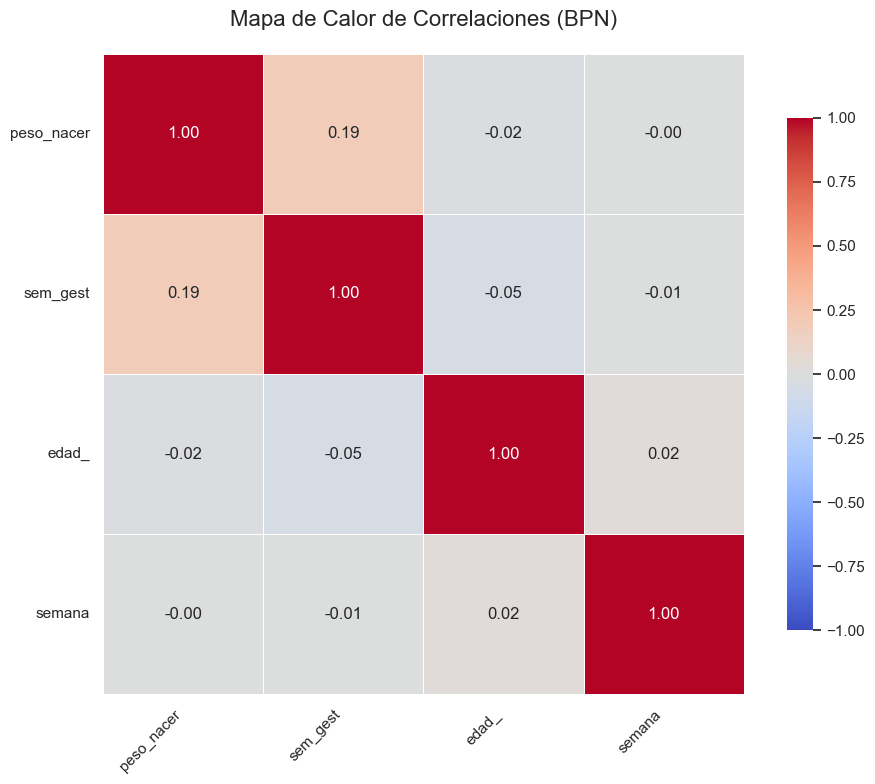

In [9]:
# 4. Matriz de correlación para Regresión
# Usamos las variables continuas confirmadas
cols_correlacion = [c for c in cols_continuas if c in df_bpn.columns]

plt.figure(figsize=(10, 8))

# Calculamos la correlación de Pearson
corr_matrix_bpn = df_bpn[cols_correlacion].corr()

# Dibujamos el mapa de calor
# vmin=-1 y vmax=1 aseguran que la escala de colores sea matemáticamente exacta
sns.heatmap(corr_matrix_bpn, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, square=True, cbar_kws={"shrink": .8},
            vmin=-1, vmax=1)

# Ajuste estético de etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Mapa de Calor de Correlaciones (BPN)", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

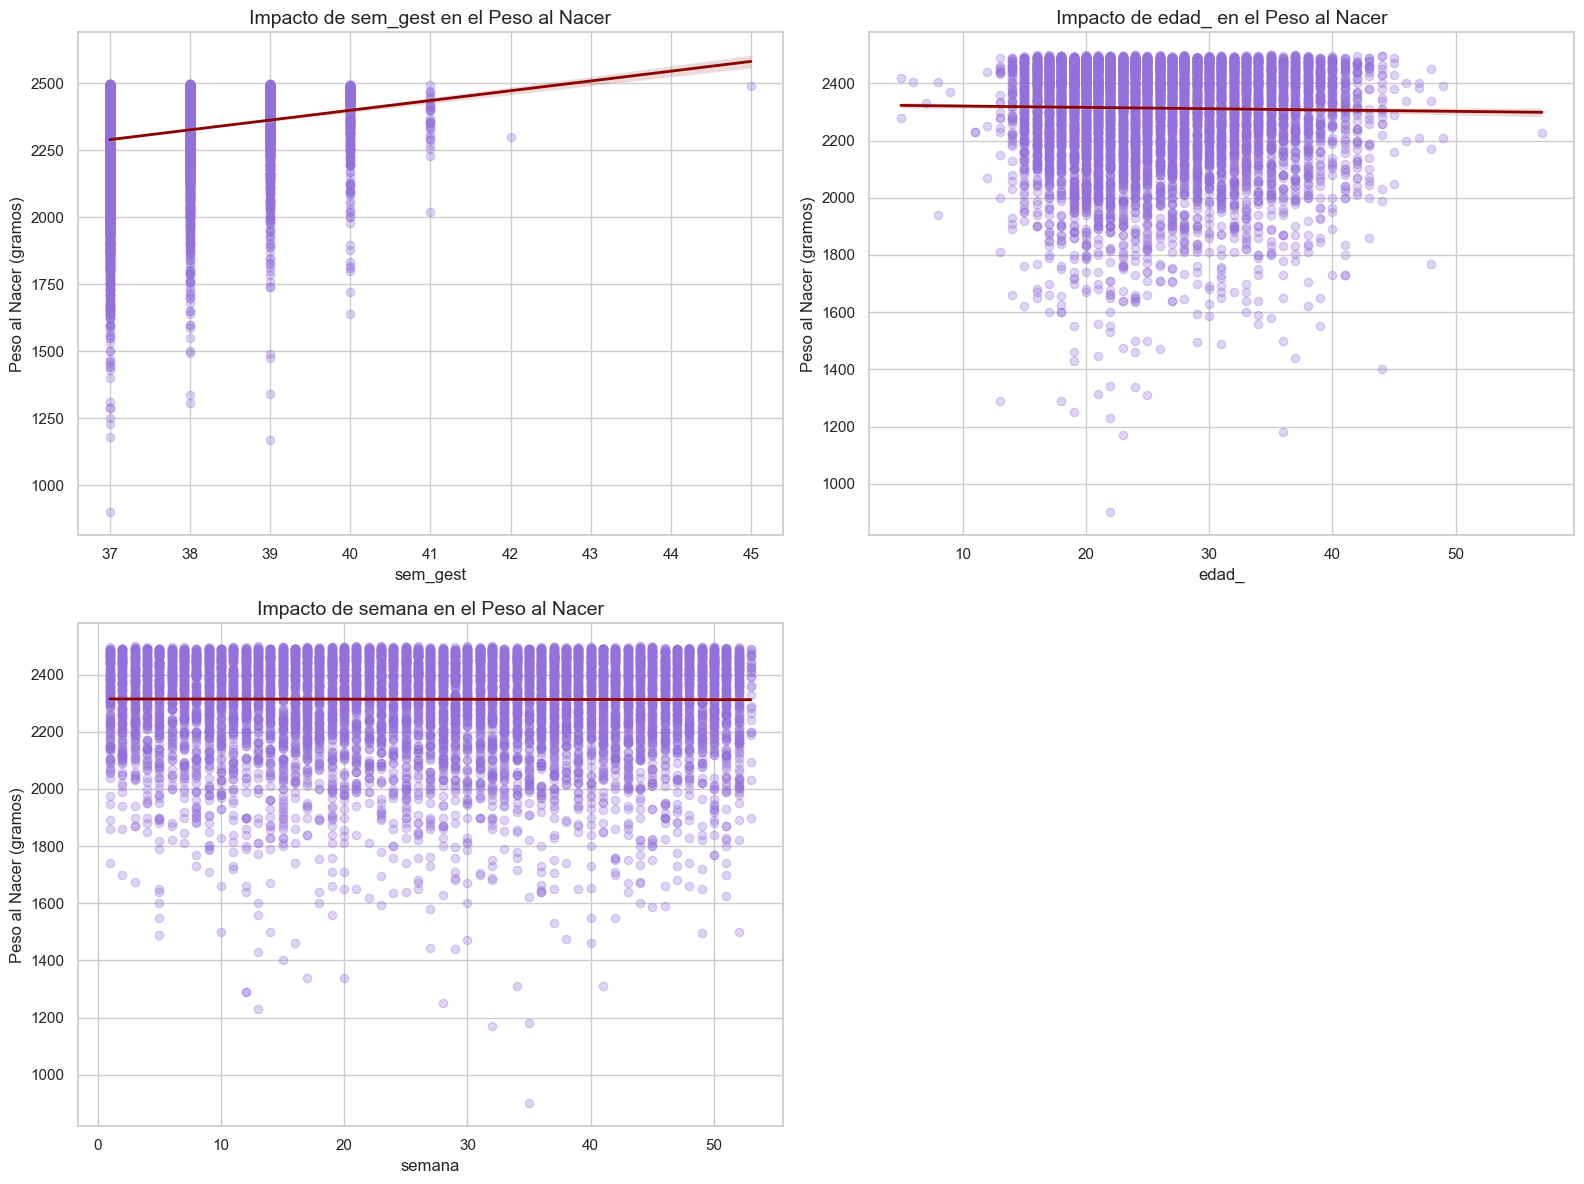

In [10]:
# 5. Scatter plots: Relación de variables continuas vs. El Target (peso_nacer)
target_bpn = 'peso_nacer'

# Seleccionamos las variables para comparar (excluyendo el peso para no compararlo consigo mismo)
vars_independientes = [c for c in cols_correlacion if c != target_bpn]

# Configuramos el lienzo (ajustamos según la cantidad de variables, probablemente 4)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(vars_independientes):
    # regplot dibuja los puntos y la línea de tendencia matemática
    sns.regplot(x=col, y=target_bpn, data=df_bpn, ax=axes[i], 
                scatter_kws={'alpha': 0.3, 'color': 'mediumpurple'}, # alpha hace los puntos transparentes
                line_kws={'color': 'darkred', 'linewidth': 2}) # Línea roja para resaltar la tendencia
    
    axes[i].set_title(f"Impacto de {col} en el Peso al Nacer", fontsize=14)
    axes[i].set_ylabel("Peso al Nacer (gramos)")
    axes[i].set_xlabel(col)

# Ocultar cuadros sobrantes si los hay
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()